In [ ]:
from google.colab import files
uploaded = files.upload()


Saving FAOSTAT_data_en_11-19-2025.csv to FAOSTAT_data_en_11-19-2025.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
faostat = pd.read_csv("FAOSTAT_data_en_11-19-2025.csv")
crop = pd.read_csv("Crop_recommendation.csv")

print(faostat.head())
print(crop.head())


  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   
2  Anise, badian, co

In [ ]:
faostat = faostat[faostat['Element'] == 'Yield']


In [ ]:
# Convert Item to string just in case
faostat['Item'] = faostat['Item'].astype(str)

# Split grouped crops
faostat['Item'] = faostat['Item'].str.split(',')

# Explode
faostat = faostat.explode('Item')

# Clean whitespace
faostat['Item'] = faostat['Item'].str.strip()


In [ ]:
faostat['Item'].value_counts().head(15)


,count
Item,
raw,120
dry,120
n.e.c.,120
green,72
in shell,65
Chillies and peppers,48
raw or retted,48
Peas,48
badian,24


In [ ]:
faostat['Item'] = faostat['Item'].str.lower()


In [ ]:
crop_mapping = {
    "apples": "apple",
    "bananas": "banana",
    "chick peas": "chickpea",
    "coconuts": "coconut",
    "coffee": "coffee",
    "seed cotton": "cotton",
    "grapes": "grapes",
    "jute": "jute",
    "lentils": "lentil",
    "maize": "maize",
    "mangoes": "mango",
    "beans": "mothbeans",
    "cantaloupes and other melons": "muskmelon",
    "oranges": "orange",
    "papayas": "papaya",
    "pigeon peas": "pigeonpeas",
    "rice": "rice",
    "watermelons": "watermelon"
}


In [ ]:
faostat['crop'] = faostat['Item'].map(crop_mapping)
faostat = faostat.dropna(subset=['crop'])


In [ ]:
print("Unique crops:", faostat['crop'].unique())
print("Count:", faostat['crop'].nunique())


Unique crops: ['apple' 'banana' 'mothbeans' 'muskmelon' 'chickpea' 'coconut' 'coffee'
 'grapes' 'jute' 'lentil' 'mango' 'orange' 'papaya' 'pigeonpeas' 'rice'
 'cotton' 'watermelon']
Count: 17


In [ ]:
faostat['crop'].nunique()


17

In [ ]:
faostat_final = faostat[['Area', 'Year', 'crop', 'Value']]
faostat_final.rename(columns={'Value': 'yield'}, inplace=True)


/tmp/ipython-input-1995939970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faostat_final.rename(columns={'Value': 'yield'}, inplace=True)


In [ ]:
faostat_final = faostat_final[faostat_final['Area'] == 'India']


In [ ]:
print(crop.columns)
print(faostat_final.columns)


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')
Index(['Area', 'Year', 'crop', 'yield'], dtype='object')


In [ ]:
print(crop.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [ ]:
crop.rename(columns={'label': 'crop'}, inplace=True)


In [ ]:
print(crop.columns)


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop'], dtype='object')


In [ ]:
merged = pd.merge(
    crop,
    faostat_final,
    how='inner',
    on='crop'
)


In [ ]:
merged['crop'].nunique()


17

In [ ]:
merged.head()


,N,P,K,temperature,humidity,ph,rainfall,crop,Area,Year,yield
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,India,2000,2850.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,India,2001,3115.8
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,India,2002,2616.3
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,India,2003,3117.7
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,India,2004,2975.6


In [ ]:
merged.shape


(40800, 11)

In [ ]:
merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40800 entries, 0 to 40799
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            40800 non-null  int64  
 1   P            40800 non-null  int64  
 2   K            40800 non-null  int64  
 3   temperature  40800 non-null  float64
 4   humidity     40800 non-null  float64
 5   ph           40800 non-null  float64
 6   rainfall     40800 non-null  float64
 7   crop         40800 non-null  object 
 8   Area         40800 non-null  object 
 9   Year         40800 non-null  int64  
 10  yield        40800 non-null  float64
dtypes: float64(5), int64(4), object(2)
memory usage: 3.4+ MB


In [ ]:
merged.describe()


,N,P,K,temperature,humidity,ph,rainfall,Year,yield
count,40800.000000,40800.000000,40800.000000,40800.000000,40800.000000,40800.000000,40800.000000,40800.000000,40800.000000
mean,54.926471,54.382353,55.301176,25.924478,73.244567,6.473346,109.511615,2011.500000,10445.894363
std,38.595259,35.944363,55.413620,5.164295,21.249891,0.820600,59.477670,6.922271,11984.114493
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,2000.000000,326.900000
25%,22.000000,26.000000,23.000000,23.251545,60.366832,6.008167,65.981700,2005.750000,900.425000
50%,39.000000,50.000000,37.500000,25.805914,81.135589,6.409440,98.192498,2011.500000,5283.200000
75%,91.000000,70.000000,52.000000,28.661994,90.774057,6.931997,149.945575,2017.250000,20552.600000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,2023.000000,44328.400000


In [ ]:
merged.duplicated().sum()


np.int64(0)

In [ ]:
merged = merged.drop_duplicates()


In [ ]:
merged.isnull().sum()


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
crop,0
Area,0
Year,0


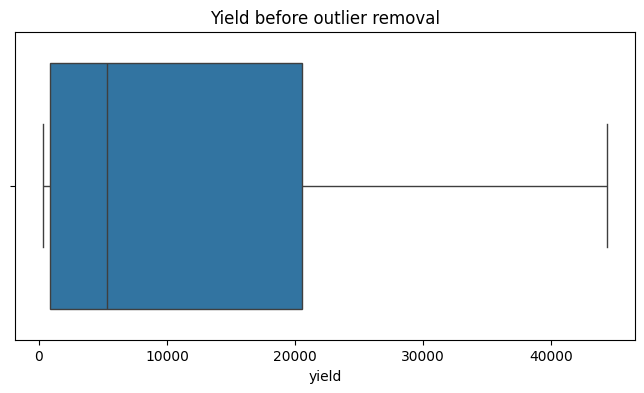

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=merged['yield'])
plt.title("Yield before outlier removal")
plt.show()


In [ ]:
Q1 = merged['yield'].quantile(0.25)
Q3 = merged['yield'].quantile(0.75)
IQR = Q3 - Q1

merged = merged[
    (merged['yield'] >= Q1 - 1.5 * IQR) &
    (merged['yield'] <= Q3 + 1.5 * IQR)
]


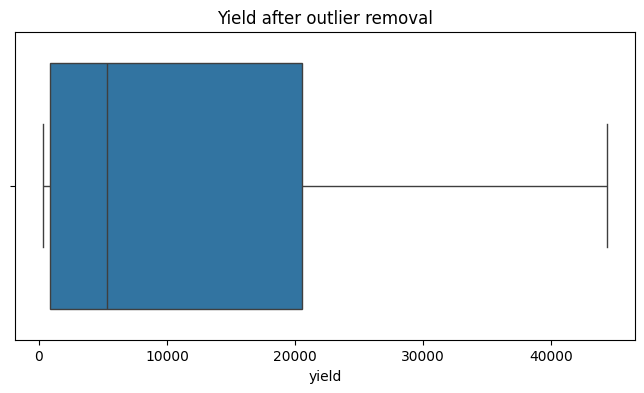

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=merged['yield'])
plt.title("Yield after outlier removal")
plt.show()


In [ ]:
merged.isnull().sum()


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
crop,0
Area,0
Year,0


In [ ]:
merged.shape


(40800, 11)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib


In [ ]:
X = merged.drop(['yield', 'Area'], axis=1)
y = merged['yield']


In [ ]:
categorical_features = ['crop']
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Year']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)


In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop']),
                                                 ('num', 'passthrough',
                                                  ['N', 'P', 'K', 'temperature',
                                                   'humidity', 'ph', 'rainfall',
                                                   'Year'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2: 0.9999751651844133
MAE: 3.791064828454152


In [ ]:
joblib.dump(model, "crop_yield_pipeline.pkl")


['crop_yield_pipeline.pkl']

In [ ]:
import sklearn
sklearn.__version__


'1.6.1'